In [1]:
import math
import pandas as pd

df = pd.read_csv("Ads_CTR_Optimisation.csv")
N, d = df.shape

In [2]:
import random

number_of_rewards_1 = [0] * d  # Tıklama sayısı alpha
number_of_rewards_0 = [0] * d  # Tıklamama sayısı beta
total_reward = 0
ads_selected = []

for user in range(N):
    selected_ad = 0
    max_random = 0

    for ad in range(d):
        random_beta = random.betavariate(number_of_rewards_1[ad] + 1, number_of_rewards_0[ad] + 1)

        if random_beta > max_random:
            max_random = random_beta
            selected_ad = ad

    ads_selected.append(selected_ad)

    reward = df.values[user, selected_ad]

    if reward == 1:
        number_of_rewards_1[selected_ad] += 1
    else:
        number_of_rewards_0[selected_ad] += 1

    total_reward += reward


In [3]:
print(f"UCB için Toplam Tıklama Sayısı: {total_reward}")
print("Reklamların Gösterilme Sayıları:", number_of_rewards_1)

UCB için Toplam Tıklama Sayısı: 2607
Reklamların Gösterilme Sayıları: [16, 19, 1, 8, 2480, 1, 9, 55, 16, 2]


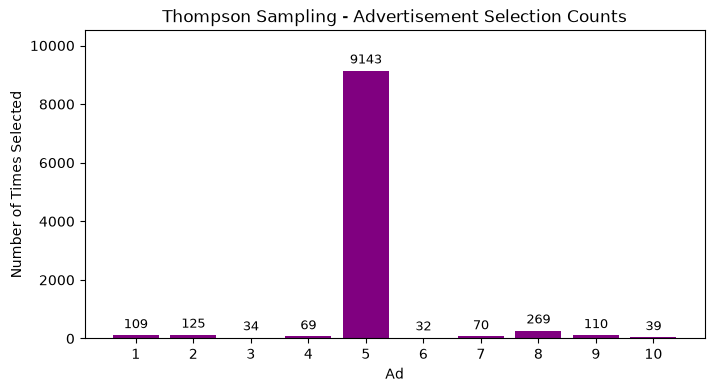

In [4]:
import matplotlib.pyplot as plt

counts = pd.Series(ads_selected).value_counts().reindex(range(d), fill_value=0)

plt.figure(figsize=(8, 4))

bars = plt.bar(range(1, d + 1), counts.values, color='purple')

plt.bar_label(bars, padding=3, fontsize=9)
plt.ylim(0, max(counts) * 1.15)

plt.title("Thompson Sampling - Advertisement Selection Counts")
plt.xlabel("Ad")
plt.ylabel("Number of Times Selected")
plt.xticks(range(1, d + 1))

plt.show()